# Sentiment Analysis

This notebook applies sentiment analysis to the cleaned YouTube comment dataset.

The analysis begins with VADER as a baseline sentiment model and examines sentiment polarity across the three content domains.

The workflow includes:
- generating sentiment scores
- assigning sentiment categories
- examining the overall sentiment distribution
- comparing sentiment across domains
- examining the relationship between sentiment and engagement

## Important Methodological Note

VADER classifications are model outputs, not ground-truth sentiment labels. The percentages and comparisons in this notebook therefore describe **VADER's classifications of the sampled comments**.

A manually annotated validation sample is created later in this notebook so that model performance can be evaluated against human judgments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
input_path = Path("../data/processed/youtube_comments_clean.csv")

df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (750, 11)


,domain,creator,video_id,video_title,comment_id,comment_text,like_count,published_at,clean_text,character_count,word_count
0,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgzKqfHI8Eags5rqHVJ4AaABAg,Learned a lot of lessons from the last time I ...,4919,2026-09-18T15:56:48Z,Learned a lot of lessons from the last time I ...,108,22
1,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugw2CZt8wqvMWpkUvml4AaABAg,18 pro series reporting lot of problems 😂pink ...,0,2026-09-26T17:23:15Z,18 pro series reporting lot of problems 😂pink ...,75,12
2,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgxUGyHsxYZkzk7qHuF4AaABAg,What game is that??? 3:16,0,2026-09-26T16:45:06Z,What game is that??? 3:16,25,5
3,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgyQxd36wlTmY5jj9_F4AaABAg,It's so cherry picking and most of the points ...,0,2026-09-26T16:19:00Z,It's so cherry picking and most of the points ...,841,150
4,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugwh_zxyYLUROYEJKwF4AaABAg,"You’ve never had thermal issues?? Holy cow, I’...",0,2026-09-26T15:12:19Z,"You’ve never had thermal issues?? Holy cow, I’...",124,22


## VADER Sentiment Scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is used as the baseline sentiment model.

It is particularly suitable for short, informal text because it considers features such as punctuation, capitalization, and common sentiment expressions.

In [3]:
analyzer = SentimentIntensityAnalyzer()

In [4]:
sample_comments = df["clean_text"].sample(10, random_state=42)

for comment in sample_comments:
    scores = analyzer.polarity_scores(comment)
    print(f"Comment: {comment}")
    print(f"Scores: {scores}")
    print()

Comment: Kurt is loafing there like a ginger bread😂 The cats in the shelter will love it ❤
Scores: {'neg': 0.055, 'neu': 0.52, 'pos': 0.425, 'compound': 0.93}

Comment: Hello from Flagstaff! My girl and i are huge fans man! Love the videos! So exciting to see u get joyride form out target haha! Keep up the amazing videos!!❤
Scores: {'neg': 0.0, 'neu': 0.501, 'pos': 0.499, 'compound': 0.9773}

Comment: I got one for $13 bucks on whatnot from dailydealzga fire guy to buy from 🔥
Scores: {'neg': 0.255, 'neu': 0.745, 'pos': 0.0, 'compound': -0.5859}

Comment: Hidden message of the video. It ALL ends with JESUS.
Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Comment: I got 50/48🎉
Scores: {'neg': 0.0, 'neu': 0.597, 'pos': 0.403, 'compound': 0.4019}

Comment: They dont sell in Canada if anyone can tell me where i could find this please DM me ❤
Scores: {'neg': 0.0, 'neu': 0.725, 'pos': 0.275, 'compound': 0.7798}

Comment: I was in here😊😊😊😊
Scores: {'neg': 0.0, 'neu': 0.4, 'pos':

In [5]:
sentiment_scores = df["clean_text"].apply(analyzer.polarity_scores)
sentiment_scores = pd.DataFrame(sentiment_scores.tolist())

sentiment_scores = sentiment_scores.rename(
    columns={
        "neg": "vader_neg",
        "neu": "vader_neu",
        "pos": "vader_pos",
        "compound": "vader_compound"
    }
)

df = pd.concat([df, sentiment_scores], axis=1)

df.head()

,domain,creator,video_id,video_title,comment_id,comment_text,like_count,published_at,clean_text,character_count,word_count,vader_neg,vader_neu,vader_pos,vader_compound
0,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgzKqfHI8Eags5rqHVJ4AaABAg,Learned a lot of lessons from the last time I ...,4919,2026-09-18T15:56:48Z,Learned a lot of lessons from the last time I ...,108,22,0.000,1.000,0.000,0.0000
1,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugw2CZt8wqvMWpkUvml4AaABAg,18 pro series reporting lot of problems 😂pink ...,0,2026-09-26T17:23:15Z,18 pro series reporting lot of problems 😂pink ...,75,12,0.247,0.753,0.000,-0.5574
2,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgxUGyHsxYZkzk7qHuF4AaABAg,What game is that??? 3:16,0,2026-09-26T16:45:06Z,What game is that??? 3:16,25,5,0.000,1.000,0.000,0.0000
3,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgyQxd36wlTmY5jj9_F4AaABAg,It's so cherry picking and most of the points ...,0,2026-09-26T16:19:00Z,It's so cherry picking and most of the points ...,841,150,0.048,0.843,0.109,0.8002
4,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugwh_zxyYLUROYEJKwF4AaABAg,"You’ve never had thermal issues?? Holy cow, I’...",0,2026-09-26T15:12:19Z,"You’ve never had thermal issues?? Holy cow, I’...",124,22,0.000,1.000,0.000,0.0000


In [6]:
df[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]].describe()

,vader_neg,vader_neu,vader_pos,vader_compound
count,750.000000,750.000000,750.000000,750.000000
mean,0.062100,0.751964,0.185931,0.270302
std,0.128183,0.228868,0.213699,0.461436
min,0.000000,0.000000,0.000000,-0.958800
25%,0.000000,0.605000,0.000000,0.000000
50%,0.000000,0.776500,0.136500,0.273200
75%,0.079000,1.000000,0.297750,0.669675
max,1.000000,1.000000,1.000000,0.995200


In [7]:
def classify_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


df["vader_sentiment"] = df["vader_compound"].apply(classify_sentiment)

df["vader_sentiment"].value_counts()

vader_sentiment
positive    410
neutral     228
negative    112
Name: count, dtype: int64

In [8]:
sentiment_summary = (
    df["vader_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_summary

vader_sentiment
positive    54.67
neutral     30.40
negative    14.93
Name: proportion, dtype: float64

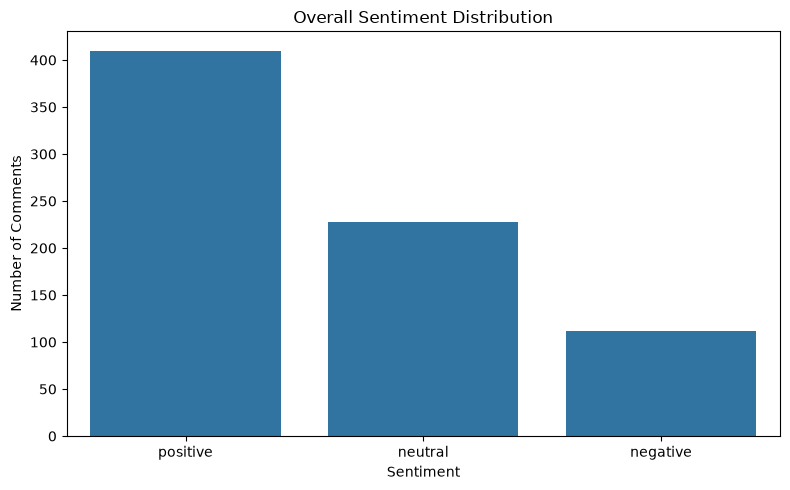

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="vader_sentiment",
    order=["positive", "neutral", "negative"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

## Sentiment Distribution by Domain

The overall sentiment distribution can hide differences between content domains.

Sentiment categories are therefore compared across technology, travel, and cats using both counts and percentages.

In [10]:
domain_sentiment_counts = pd.crosstab(
    df["domain"],
    df["vader_sentiment"]
)[["positive", "neutral", "negative"]]

domain_sentiment_counts

vader_sentiment,positive,neutral,negative
domain,,,
cats,182,47,21
technology,103,83,64
travel,125,98,27


In [11]:
domain_sentiment_pct = (
    pd.crosstab(
        df["domain"],
        df["vader_sentiment"],
        normalize="index"
    )[["positive", "neutral", "negative"]]
    .mul(100)
    .round(2)
)

domain_sentiment_pct

vader_sentiment,positive,neutral,negative
domain,,,
cats,72.8,18.8,8.4
technology,41.2,33.2,25.6
travel,50.0,39.2,10.8


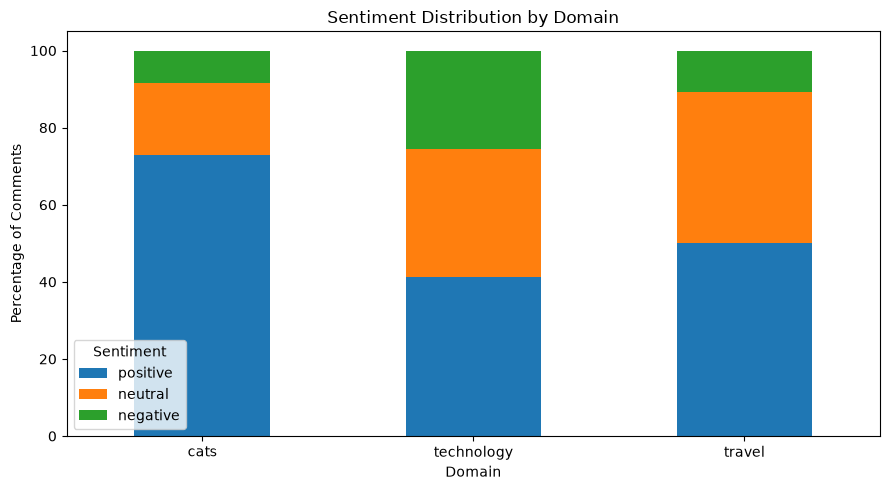

In [12]:
domain_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Sentiment Distribution by Domain")
plt.xlabel("Domain")
plt.ylabel("Percentage of Comments")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

### Observation

VADER sentiment classifications differ across the three sampled domains.

VADER classified the cats sample with the highest proportion of positive comments (72.8%), while technology had the highest proportion of negative comments (25.6%). Travel had 50.0% positive, 39.2% neutral, and 10.8% negative comments.

These differences describe the sampled comments rather than the broader audiences for each content domain. The results may also reflect differences in individual creators, video topics, and the specific videos selected.

## Sentiment Intensity by Domain

Sentiment categories provide a simplified view of polarity. The VADER compound score provides additional information about the strength and direction of sentiment.

The distribution of compound scores is therefore compared across the three domains.

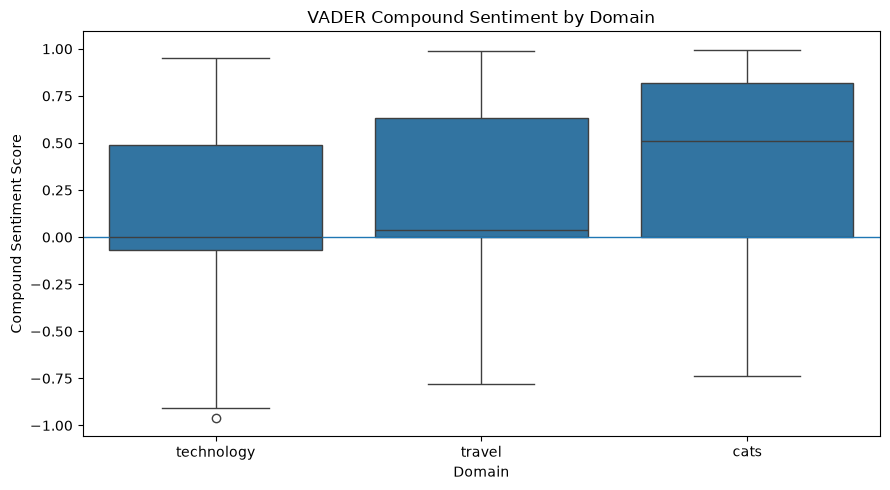

In [13]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="domain",
    y="vader_compound"
)

plt.axhline(0, linewidth=1)

plt.title("VADER Compound Sentiment by Domain")
plt.xlabel("Domain")
plt.ylabel("Compound Sentiment Score")

plt.tight_layout()
plt.show()

### Observation

The VADER compound scores show differences in sentiment intensity across the sampled domains. The cats comments had the highest mean (0.434) and median (0.511) compound scores, while technology had the lowest mean (0.117) and a median of 0.000. Travel fell between the two, with a mean of 0.260 and median of 0.039.

All three domains contained both positive and negative sentiment, indicating variation within each domain. These results describe the selected comments and should not be generalized to the broader audiences without additional sampling.

In [14]:
sentiment_intensity = (
    df.groupby("domain")["vader_compound"]
      .agg(["mean", "median", "std", "min", "max"])
      .round(3)
)

sentiment_intensity

,mean,median,std,min,max
domain,,,,,
cats,0.434,0.511,0.430,-0.735,0.995
technology,0.117,0.000,0.476,-0.959,0.951
travel,0.260,0.039,0.422,-0.778,0.990


## Sentiment and Audience Engagement

This section examines whether comments with different sentiment scores receive different levels of engagement.

Because comment likes are highly skewed, the analysis uses log-transformed likes. The relationship is examined descriptively rather than interpreted as causal.

In [15]:
engagement_by_sentiment = (
    df.groupby("vader_sentiment")["like_count"]
      .agg(["count", "mean", "median", "max"])
      .round(2)
)

engagement_by_sentiment

,count,mean,median,max
vader_sentiment,,,,
negative,112,0.09,0.0,3
neutral,228,21.82,0.0,4919
positive,410,11.51,0.0,2976


In [16]:
df["log_like_count"] = np.log1p(df["like_count"])

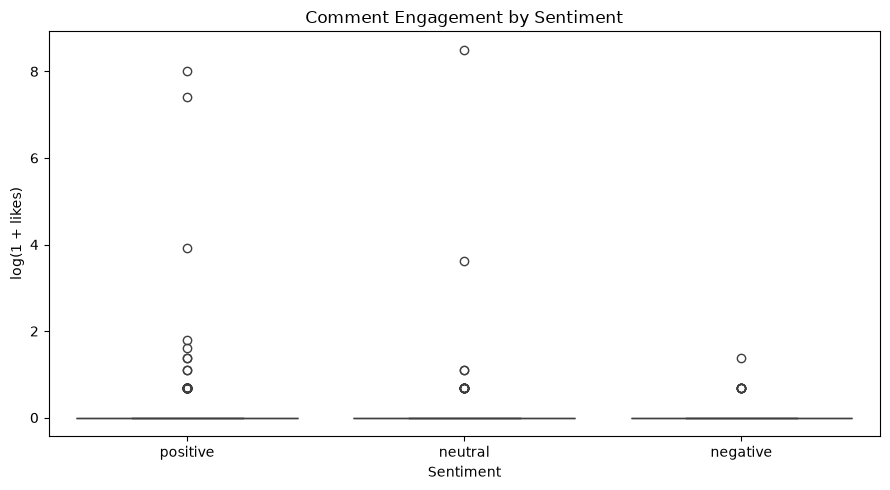

In [17]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="vader_sentiment",
    y="log_like_count",
    order=["positive", "neutral", "negative"]
)

plt.title("Comment Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + likes)")

plt.tight_layout()
plt.show()

In [18]:
engagement_log_summary = (
    df.groupby("vader_sentiment")["log_like_count"]
      .agg(["mean", "median", "max"])
      .round(3)
)

engagement_log_summary

,mean,median,max
vader_sentiment,,,
negative,0.056,0.0,1.386
neutral,0.111,0.0,8.501
positive,0.135,0.0,7.999


In [19]:
nonzero_engagement = (
    df.assign(has_like=df["like_count"] > 0)
      .groupby("vader_sentiment")["has_like"]
      .mean()
      .mul(100)
      .round(2)
)

nonzero_engagement

vader_sentiment
negative     7.14
neutral      8.77
positive    11.95
Name: has_like, dtype: float64

In [20]:
sentiment_engagement_corr = df["vader_compound"].corr(
    df["like_count"],
    method="spearman"
)

print("Spearman correlation:", round(sentiment_engagement_corr, 3))

Spearman correlation: 0.092


### Observation

VADER sentiment intensity showed a very weak positive association with comment likes (Spearman ρ = 0.092). The proportion of comments receiving at least one like was 11.95% for positive comments, 8.77% for neutral comments, and 7.14% for negative comments.

However, most comments received no likes, and a small number of highly liked comments created substantial skew in the engagement data. Therefore, the relationship between sentiment and engagement appears weak in this sample and should not be interpreted as causal.

## VADER Sentiment Examples

Examining individual comments helps identify how VADER handles clear positive and negative language, emojis, informal expressions, humor, and context-dependent comments.

Comments with compound scores close to zero are also examined because they represent comments with little overall polarity according to VADER.

In [21]:
top_positive = (
    df.sort_values("vader_compound", ascending=False)
      [["domain", "video_title", "clean_text", "vader_compound"]]
      .head(10)
)

top_positive

,domain,video_title,clean_text,vader_compound
744,cats,"I finally tried cat ""talking buttons""",The objective is that the pet understands the ...,0.9952
307,travel,"I Tried the ""Top 10 Things To Do"" in America","Jeff🎉🎉,,😊😊😊🎉😊,❤❤",0.9902
497,travel,I Took the Longest Train Ride in America,I love you ❤ your videos are just really so ca...,0.9872
554,cats,Minute to Win it - Cat Edition,Kurt's proud tail when he got the toy 😂😂🥰🥰🥰,0.9846
672,cats,This is Not an Ordinary Cat Stroller...,I like it.😊❤❤❤❤❤,0.9842
535,cats,I don't know what I was thinking,😂 lol that ginger and white cat that was in fr...,0.9841
375,travel,I Visited the Top 10 Places in America - Grand...,"I’m 1 month late, but I hope Ryan sees this!!!...",0.9834
642,cats,my cats tried whatever my subscribers suggested,12:39 ❤❤. Can't really judge on the 1st time y...,0.9826
382,travel,I Visited the Top 10 Places in America - Grand...,"Yooo ryannn, you should do a challenge where y...",0.9822
733,cats,"I finally tried cat ""talking buttons""",Put a treat on top of the button and a ball on...,0.9802


In [22]:
top_negative = (
    df.sort_values("vader_compound", ascending=True)
      [["domain", "video_title", "clean_text", "vader_compound"]]
      .head(10)
)
top_negative

,domain,video_title,clean_text,vader_compound
103,technology,I Tested YouTubers' Favourite Products,"I get he's not a fan of Jesse's Brick, but put...",-0.9588
129,technology,I Tested YouTubers' Favourite Products,4:29 what😭😭😭😭,-0.9081
212,technology,The Gaming Market is Starting to Break.,So the entire thing comes down to greedy compa...,-0.9074
224,technology,The Gaming Market is Starting to Break.,"WTF.... those twisted companies, directives, d...",-0.8576
231,technology,The Gaming Market is Starting to Break.,Just stop buying gaming shit let it fail,-0.8519
222,technology,The Gaming Market is Starting to Break.,They said A.I will kill us with tecnology. The...,-0.8519
71,technology,"I spent $12,000 on the THINNEST Tech",This is the future. No right to repair. No loc...,-0.8360
97,technology,"I spent $12,000 on the THINNEST Tech",17:39 what the hell is bro reading😭,-0.8271
380,travel,I Visited the Top 10 Places in America - Grand...,I went to almost all the places like 2 days af...,-0.7783
220,technology,The Gaming Market is Starting to Break.,"You don't even own the games anymore, they can...",-0.7767


In [23]:
closest_to_neutral = (
    df.assign(abs_compound=df["vader_compound"].abs())
      .sort_values("abs_compound")
      [["domain", "video_title", "clean_text", "vader_compound"]]
      .head(15)
)

closest_to_neutral

,domain,video_title,clean_text,vader_compound
0,technology,iPhone 18 Pro Review - My Last iPhone?,Learned a lot of lessons from the last time I ...,0.0
328,travel,"I Tried the ""Top 10 Things To Do"" in America",38:16 TADCC,0.0
319,travel,"I Tried the ""Top 10 Things To Do"" in America",I live in new York!,0.0
317,travel,"I Tried the ""Top 10 Things To Do"" in America",isn't washington monument THE SPIDERMAN TOWER,0.0
309,travel,"I Tried the ""Top 10 Things To Do"" in America",My turn is named after Lincoln by the way it’s...,0.0
306,travel,"I Tried the ""Top 10 Things To Do"" in America",Two words. Passenger pigeon. The most American...,0.0
298,travel,How Many Countries Can I Visit in 7 Days?,If they sold it in uk i would buy,0.0
297,travel,How Many Countries Can I Visit in 7 Days?,голопом по Европам,0.0
330,travel,"I Tried the ""Top 10 Things To Do"" in America",24:46 cookie run Kingdom in the back,0.0
295,travel,How Many Countries Can I Visit in 7 Days?,Dantic??,0.0


## Sentiment Distribution by Video

Domain-level sentiment can hide variation between individual videos. This section examines sentiment composition at the video level.

In [24]:
video_sentiment_pct = (
    pd.crosstab(
        df["video_title"],
        df["vader_sentiment"],
        normalize="index"
    )[["positive", "neutral", "negative"]]
    .mul(100)
    .round(2)
)

video_sentiment_pct

vader_sentiment,positive,neutral,negative
video_title,,,
How Many Countries Can I Visit in 7 Days?,28.0,64.0,8.0
I Tested YouTubers' Favourite Products,38.0,30.0,32.0
I Took the Longest Train Ride in America,50.0,42.0,8.0
"I Tried the ""Top 10 Things To Do"" in America",66.0,22.0,12.0
I Visited the Top 10 Places in America - Grand Canyon,50.0,36.0,14.0
I Visited the Top 10 Places in America - Los Angeles,56.0,32.0,12.0
I don't know what I was thinking,52.0,34.0,14.0
"I finally tried cat ""talking buttons""",82.0,12.0,6.0
"I spent $12,000 on the THINNEST Tech",26.0,50.0,24.0


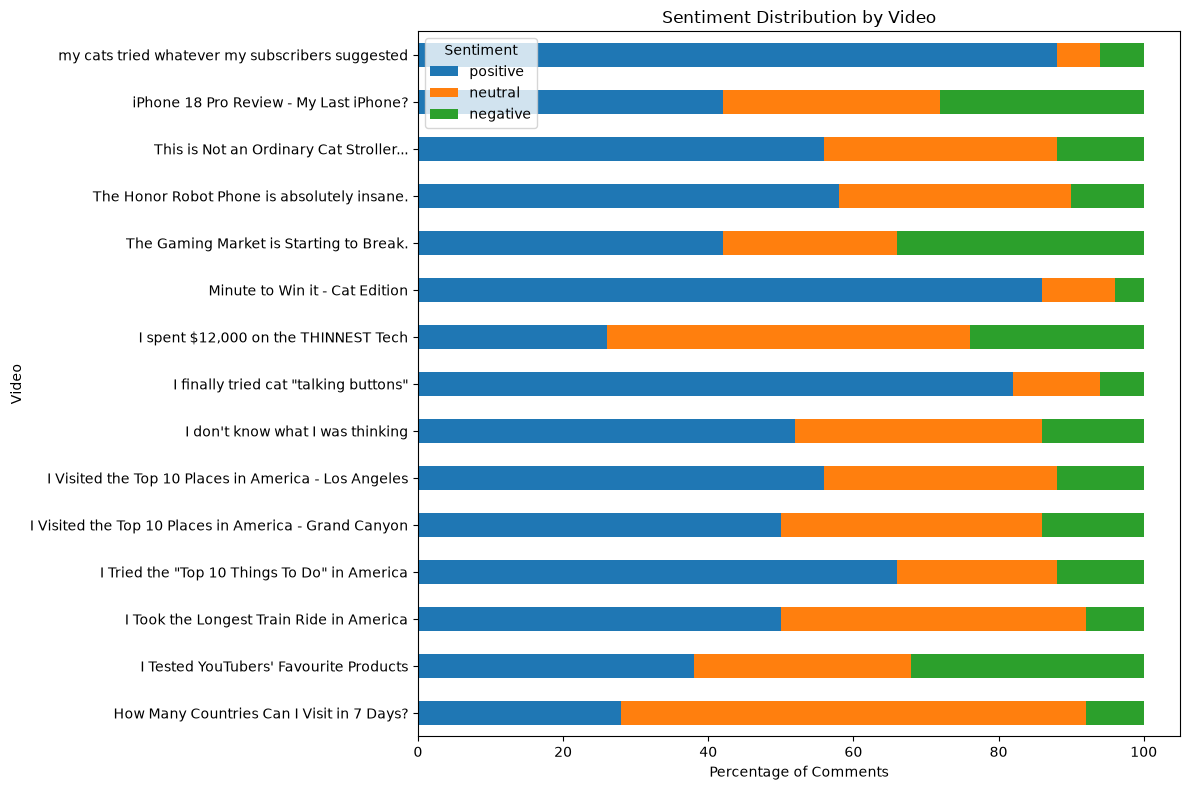

In [25]:
video_sentiment_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8)
)

plt.title("Sentiment Distribution by Video")
plt.xlabel("Percentage of Comments")
plt.ylabel("Video")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

### Observation

Sentiment composition varies substantially across individual videos, even within the same domain. This indicates that domain-level differences may partly reflect the topics and characteristics of the selected videos rather than the content domain alone.

Therefore, the domain-level sentiment results should be interpreted as descriptive findings from the selected videos rather than as general characteristics of technology, travel, or cat audiences.

## Human Validation Sample

VADER provides model-generated sentiment classifications; these labels should not be treated as ground truth.

A stratified sample of 120 comments is prepared for manual annotation:
- 40 technology comments
- 40 travel comments
- 40 cats comments

The VADER label is intentionally excluded from the annotation file so that the manual labels are not influenced by the model output.

In [26]:
validation_sample = (
    df.groupby("domain", group_keys=False)
      .sample(n=40, random_state=42)
      [["comment_id", "domain", "creator", "video_id", "video_title", "clean_text"]]
      .copy()
)

validation_sample["human_sentiment"] = ""

validation_path = Path("../data/processed/vader_validation_sample.csv")
validation_sample.to_csv(validation_path, index=False)

print("Validation sample shape:", validation_sample.shape)
print("Comments per domain:")
print(validation_sample["domain"].value_counts())
print(f"Saved annotation file to: {validation_path}")

Validation sample shape: (120, 7)
Comments per domain:
domain
cats          40
technology    40
travel        40
Name: count, dtype: int64
Saved annotation file to: ../data/processed/vader_validation_sample.csv


### Manual Annotation

Open `data/processed/vader_validation_sample.csv` and fill the `human_sentiment` column using:

- `positive`
- `neutral`
- `negative`

The manual labels will later be compared with VADER and a transformer model to evaluate model performance.

In [27]:
output_path = Path("../data/processed/youtube_comments_vader.csv")

df.to_csv(output_path, index=False)

print(f"Saved VADER-enriched dataset to: {output_path}")

Saved VADER-enriched dataset to: ../data/processed/youtube_comments_vader.csv


In [28]:
vader_df = pd.read_csv(output_path)

print("Saved dataset shape:", vader_df.shape)
print("Columns:")
print(vader_df.columns.tolist())

Saved dataset shape: (750, 17)
Columns:
['domain', 'creator', 'video_id', 'video_title', 'comment_id', 'comment_text', 'like_count', 'published_at', 'clean_text', 'character_count', 'word_count', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_sentiment', 'log_like_count']
